# Probabilistic Error Cancellation: from quasiprobabilities to practice

<div style="font-size:1.05em">A QOSF Monthly Challenge</div>

**Author:** Arturo Alejandro Arvizu Velazquez

email: space.didgeridoo@gmail.com

github: [arvizu-god](https://github.com/arvizu-god)

---

Near-term quantum devices are noisy. Every gate leaks a little information into the
environment, so the expectation value we read out at the end of a circuit is *biased*
away from the value an ideal device would have given. **Quantum error mitigation (QEM)**
is the art of recovering an estimate of that ideal value from noisy runs alone — without
the qubit overhead of full error correction.

In this challenge you will build one of the foundational QEM methods from its component
parts: **Probabilistic Error Cancellation (PEC)**, introduced by Temme, Bravyi and
Gambetta in 2017. You will implement it for the friendliest possible noise model
(depolarizing noise), apply it to a GHZ state-preparation circuit, and then confront the
property that makes PEC both elegant and limited: it removes the bias *exactly*, but its
cost grows *exponentially* with the size of the computation.

### What you will do
1. Write the observable and the depolarizing quasiprobability tables.
2. Compute the sampling overhead $\gamma$ from the circuit.
3. Implement the Monte-Carlo sampling step that is the heart of PEC.
4. Assemble the unbiased PEC estimator and compare *ideal*, *noisy*, and *PEC* results.
5. Measure the variance–overhead trade-off and see why PEC does not scale.

### Table of contents
- [0. Setup](#setup)
- [1. Theory](#theory)
  - [1.1 Noise, channels, and bias](#problem)
  - [1.2 Notation used throughout](#notation)
  - [1.3 Probabilistic error cancellation in general](#pec-general)
  - [1.4 The depolarizing model and its quasiprobabilities](#dp)
- [2. The circuit: GHZ](#circuit)
- [3. The noise model](#noise)
- [4. Building PEC](#build)
- [5. Results: does PEC work?](#results)
- [6. The trade-off: exponential cost](#tradeoff)
- [7. Conclusions &amp; bonus](#conclusions)
- [References](#refs)

> **Prerequisites.** You should be comfortable building circuits in Qiskit, know what a
> quantum gate and an expectation value are, and have seen the idea of a noise channel
> before. You will **not** be asked to derive any of the PEC mathematics — every formula
> you need is given to you. Your job is to implement and interpret.


<a id="setup"></a>
## 0. Setup

This challenge runs entirely on a local simulator — **no IBM Quantum account and no hardware queue** are needed.
You will need Qiskit, Qiskit Aer, NumPy, and Matplotlib.

If `qiskit_aer` is missing in your environment, run the installation cell below once, restart the kernel if needed, and then continue.


In [1]:
# Uncomment this line if the required packages are not installed:
# %pip install -r requirements.txt

In [2]:
# === Imports and global configuration ===

import numpy as np
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error

SEED = 42
EPS = 0.02
N_DEMO = 4
SHOTS = 512
PEC_SAMPLES = 100

# Fixed label order used throughout the PEC sampler.
PAULI_1Q_LABELS = np.array(["X", "Y", "Z", "I"])
PAULI_2Q_LABELS = np.array(
    ["II"] + [a + b for a in "IXYZ" for b in "IXYZ" if a + b != "II"]
)

IGNORED_OPS = {"measure", "barrier", "delay", "reset", "save_density_matrix"}

print("Setup complete")

Setup complete


In [3]:
# === Autograder ===
# Keep grader.py in the same folder as this notebook.
import importlib
import grader
importlib.reload(grader)
from grader import (
    grade_ex1, grade_ex2, grade_ex3, grade_ex4, grade_ex5, grade_ex6,
    grade_ex7, grade_ex8, grade_ex9, grade_ex10, grade_ex11,
)

<a id="theory"></a>
# 1. Theory

<a id="problem"></a>
## 1.1 Noise, channels, and bias

It is convenient to describe a quantum gate not by its unitary matrix but by the *channel*
it induces on density matrices. An ideal gate $U$ acts as the unitary channel
$\mathcal{U}(\rho) = U\rho U^{\dagger}$. On real hardware the gate is followed by some error
process $\mathcal{N}$, so the operation we actually apply is the **noisy channel**

$$
\mathcal{O} \;=\; \mathcal{N}\circ\mathcal{U}.
$$

The quantity we ultimately care about is an expectation value
$\langle A\rangle = \operatorname{Tr}[A\,\rho]$ of some observable $A$ on the final state.
Write $E^{*}$ for the **ideal** (noise-free) expectation value and $\rho$ for the noisy
output state. Estimating $\operatorname{Tr}[A\rho]$ from a finite number of shots
$N_{\text{cir}}$ introduces two distinct kinds of error, which it pays to keep separate:

$$
\mathrm{MSE}[\hat{A}] \;=\; \underbrace{\big(\mathbb{E}[\hat{A}]-E^{*}\big)^{2}}_{\text{bias}^2}
\;+\; \underbrace{\operatorname{Var}[\hat{A}]}_{\text{variance (shot noise)}}.
$$

The variance term is *statistical*: it shrinks as $1/N_{\text{cir}}$ when you take more
shots. The bias term is *systematic*: it comes from the noise itself and **does not go away
no matter how many shots you take.** A raw noisy estimator is biased, and that bias is the
real enemy.

Error mitigation attacks the bias. The main observation is
that reducing bias generally *increases* variance, so you pay for accuracy with extra
sampling. PEC is the method that makes this trade-off completely explicit.


<a id="notation"></a>
## 1.2 Notation used throughout

| Symbol | Meaning |
|---|---|
| $n$ | number of qubits |
| $\epsilon$ | noise strength (depolarizing probability), $\epsilon\in[0,1)$ |
| $\mathcal{U}$, $U$ | ideal gate, as a channel / as a unitary |
| $\mathcal{D}_{k,\epsilon}$ | $k$-qubit depolarizing channel |
| $\mathcal{O}_\alpha$ | a noisy operation that the device can actually run |
| $A$ | observable to be estimated (here $A = Z^{\otimes n}$) |
| $E^{*}$ | ideal (noise-free) expectation value $\operatorname{Tr}[A\,\mathcal{U}(\rho)]$ |
| $\hat{E}$ | the PEC estimator of $E^{*}$ |
| $L_1,\;L_2$ | number of single-qubit gates / number of CNOTs in the circuit |
| $p_1,\;p_2$ | Pauli-insertion probabilities (1-qubit / 2-qubit) |
| $\eta_\alpha$ | quasiprobability coefficients (real, possibly negative) |
| $\sigma=(-1)^{r}$ | sign of a sampled circuit; $r$ = number of inserted Paulis |
| $\gamma_1,\;\gamma_2,\;\gamma$ | sampling overhead per 1q gate / per CNOT / for the whole circuit |
| $M$ | number of Monte-Carlo samples |
| $\delta$ | target additive precision on $E^{*}$ |

Throughout, "channel" means a completely positive, trace-preserving (CPTP) map, and
$\langle\,\cdot\,\rangle$ denotes an expectation value in the computational ($Z$) basis.


<a id="pec-general"></a>
## 1.3 Probabilistic error cancellation in general

On a noisy device we cannot apply an ideal gate $\mathcal{U}$ directly; we can only apply
*noisy* operations $\mathcal{O}_\alpha$ drawn from some basis $\Omega$ that the hardware
supports. PEC rests on one linear-algebra observation: although the inverse $\mathcal{N}^{-1}$
of a noise channel is not itself a physical channel, the ideal gate can still be written as a
**real linear combination** of physical noisy operations,

$$
\mathcal{U} \;=\; \sum_{\alpha} \eta_\alpha\,\mathcal{O}_\alpha, \qquad \eta_\alpha\in\mathbb{R}.
$$

Some of the coefficients $\eta_\alpha$ are *negative*. This is exactly why the combination
is called a **quasiprobability** representation (QPR) rather than a probability. Collecting
the total weight

$$
\gamma \;=\; \sum_\alpha |\eta_\alpha| \;\ge\; 1,
$$

we can rewrite the very same identity as a *signed, rescaled average* over a genuine
probability distribution $P(\alpha)=|\eta_\alpha|/\gamma$ with signs
$\sigma(\alpha)=\operatorname{sgn}(\eta_\alpha)\in\{+1,-1\}$:

$$
\mathcal{U} \;=\; \gamma \sum_{\alpha} P(\alpha)\,\sigma(\alpha)\,\mathcal{O}_\alpha.
\tag{QPR}
$$

For a full circuit the decomposition is built **gate by gate**, for each ideal gate one
solves a small linear program that minimises $\sum_\alpha|\eta_\alpha|$ subject to
reproducing that gate and the per-gate overheads simply multiply:
$\gamma_{\text{circuit}} = \prod_{\text{gates}}\gamma_{\text{gate}}$.

**The estimator.** Substituting the QPR into $E^{*}=\operatorname{Tr}[A\,\mathcal{U}(\rho)]$ turns
the ideal expectation value into a signed average of *noisy* expectation values. This yields
an **unbiased** Monte-Carlo estimator: draw $M$ circuits $\alpha_1,\dots,\alpha_M$ from
$P(\alpha)$, run each on the noisy device, read out $A$, multiply by the circuit's sign, and
rescale by $\gamma$:

$$
\hat{E} \;=\; \frac{\gamma}{M}\sum_{a=1}^{M}\sigma(\alpha_a)\,\langle x_a|A|x_a\rangle
\;\xrightarrow[M\to\infty]{}\; E^{*}.
$$

In words: *sample noisy circuits, flip the sign on some of them, average, and multiply by
$\gamma$.* The negative coefficients are what let the noise cancel on average.

**The cost.** Unbiasedness is not free; the price is **variance**. Because every sample is
scaled by $\gamma$, the estimator's variance scales like $\gamma^{2}$, and to reach an
additive precision $\delta$ one needs of order

$$
\boxed{\;M \;\approx\; \left(\frac{\gamma}{\delta}\right)^{2}\;}
$$

samples. Equivalently, relative to running the bare noisy circuit, PEC carries a *sampling
overhead* $C \approx \gamma^{2}$. This is the bias–variance trade-off made quantitative: the
bias drops to zero, the variance is multiplied by $\gamma^{2}$. Since $\gamma$ is a product
over gates, it grows exponentially with circuit size — the fundamental limitation we will
measure directly in Section 6.


<a id="dp"></a>
## 1.4 The depolarizing model and its quasiprobabilities

We use the **depolarizing channel**, the friendliest noise model for PEC because its inverse
decomposes neatly over Pauli operations. On $k$ qubits it is

$$
\mathcal{D}_{k,\epsilon}(\rho) \;=\; (1-\epsilon)\,\rho \;+\; \epsilon\,\frac{\mathbb{I}}{2^{k}},
$$

i.e. with probability $\epsilon$ the state is replaced by the maximally mixed state, and with
probability $1-\epsilon$ nothing happens. A noisy gate is modelled as $\mathcal{D}_k\mathcal{U}$:
the ideal gate followed by depolarizing noise.

**Inverting one single-qubit gate.** Looking for $\mathcal{D}_1^{-1}$ as a combination of the
four single-qubit Pauli channels,

$$
\mathcal{D}_1^{-1} \;=\; \eta_1\,\mathcal{I} + \eta_2\,\mathcal{X} + \eta_3\,\mathcal{Y} + \eta_4\,\mathcal{Z},
$$

the minimal-$\sum|\eta|$ solution is
$\eta_1 = 1 + \tfrac{3\epsilon}{4(1-\epsilon)}$ and
$\eta_2=\eta_3=\eta_4 = -\tfrac{\epsilon}{4(1-\epsilon)}$. This gives a per-gate overhead and a
sampling distribution

$$
\gamma_1 \;=\; \sum_\alpha|\eta_\alpha| \;=\; \frac{2+\epsilon}{2(1-\epsilon)},
\qquad
p_1 \;=\; \frac{\epsilon}{4+2\epsilon},
\qquad
P(X)=P(Y)=P(Z)=p_1,\quad P(I)=1-3p_1.
$$

**Inverting one CNOT.** Doing the same for $\mathcal{D}_2^{-1}$ over the 16 two-qubit Pauli
pairs $\{I,X,Y,Z\}^{\otimes 2}$ gives

$$
\gamma_2 \;=\; \frac{16+14\epsilon}{16(1-\epsilon)} \;=\; \frac{1 + 7\epsilon/8}{1-\epsilon},
\qquad
p_2 \;=\; \frac{\epsilon}{16+14\epsilon},
$$

with each of the 15 non-identity pairs carrying probability $p_2$ and the identity pair
$II$ carrying $1-15p_2$.

**The three-step recipe** (this is exactly what you will implement). Starting from the ideal
circuit:
1. after each **single-qubit** gate, insert $X$, $Y$, or $Z$, each with probability $p_1$
   (and do nothing with probability $1-3p_1$);
2. after each **CNOT**, insert one of the 15 non-identity Pauli pairs, each with probability
   $p_2$ (and do nothing with probability $1-15p_2$);
3. record the sign $\sigma=(-1)^{r}$, where $r$ is the total number of non-identity Paulis
   inserted.

**The total overhead.** With $L_1$ single-qubit gates and $L_2$ CNOTs,

$$
\boxed{\;\gamma \;=\; \gamma_1^{\,L_1}\,\gamma_2^{\,L_2}\;}
\qquad\Longrightarrow\qquad
\gamma \;\approx\; 1 + \epsilon\!\left(\tfrac{3}{2}L_1 + \tfrac{15}{8}L_2\right)
\ \ \text{for small }\epsilon.
$$

Note that $\gamma_1,\gamma_2\to 1$ as $\epsilon\to 0$ (no noise, no overhead), and that
$\gamma$ grows exponentially in the gate count. Hold on to that fact — it is the punchline of
Section 6.

<div class="alert alert-block alert-info">
<b>Why these particular numbers?</b> The decomposition above is not just one convenient choice. Takagi (2021) proved that, for depolarizing noise, no decomposition over *any* physically implementable operations can do better: the optimal overhead is γₒₚₜ = [1 + (1 − 2/d²)ε]/(1 − ε), which gives γ₁ for one qubit (d = 2) and γ₂ for a CNOT (d = 4). So the Temme recipe is optimal, and the overheads you compute are the best anyone can hope for under this model.
</div>

<div class="alert alert-block alert-warning">
<b>An important fact about PEC.</b> PEC is unbiased <i>only if</i> the quasiprobability
tables invert the noise that is <i>actually</i> on the device. In this notebook we control the
simulator, so the noise we model and the noise we invert are identical by construction, and
PEC is exactly unbiased. On real hardware you must first <i>characterise</i> the noise
accurately (e.g. via gate-set tomography), and any mismatch between model and reality leaves a
residual bias. This characterisation requirement is the single biggest practical limitation
of PEC.
</div>


<a id="circuit"></a>
# 2. The circuit: GHZ state preparation

We test PEC on the standard $n$-qubit GHZ preparation circuit:

$$
|\mathrm{GHZ}_n\rangle
= \frac{1}{\sqrt{2}}\left(|0\rangle^{\otimes n}+|1\rangle^{\otimes n}\right).
$$

The circuit uses one Hadamard gate on qubit $0$, followed by a CNOT ladder
$0\to1\to2\to\cdots\to n-1$, and then computational-basis measurements on all qubits.

The observable used in the notebook is

$$
A = Z^{\otimes n}.
$$

For the ideal GHZ state,

$$
\langle Z^{\otimes n} \rangle_{\mathrm{GHZ}_n}
= \frac{1 + (-1)^n}{2}.
$$

So the ideal theoretical value is $+1$ for even $n$ and $0$ for odd $n$. In the numerical
sections below we use `N_DEMO = 4`, so the target value is exactly $+1$.


<a id="exercise_1"></a>
<div class="alert alert-block alert-success">
<b>Exercise 1 — GHZ preparation circuit</b>

<b>Your goal:</b> implement a function `ghz_circuit(n)` that returns the measured GHZ preparation circuit.

<b>Input:</b> integer `n`, the number of qubits. Use `n >= 2`.

<b>Output:</b> a `QuantumCircuit` with:
<ul>
<li>one Hadamard gate on qubit 0,</li>
<li>a CNOT ladder `cx(0, 1), cx(1, 2), ..., cx(n-2, n-1)`,</li>
<li>measurements on all qubits, using `measure_all()` or equivalent.</li>
</ul>

Do not add the inverse GHZ circuit. This is a preparation circuit only.
</div>


In [4]:
# === Exercise 1 ===
# Define: ghz_circuit(n: int) -> QuantumCircuit
# Input: n >= 2.
# Output: measured GHZ preparation circuit on n qubits.

def ghz_circuit(n: int) -> QuantumCircuit:
    if n < 2:
        raise ValueError("Use n >= 2 for a GHZ circuit.")

    qc = QuantumCircuit(n)
    qc.h(0)
    for i in range(n - 1):
        qc.cx(i, i + 1)
    qc.measure_all()
    return qc

In [5]:
# === Check Exercise 1 ===
grade_ex1(ghz_circuit)

Exercise 1: PASS


True

In [6]:
# Visualise the circuit used in the numerical examples.
qc_demo = ghz_circuit(N_DEMO)
qc_demo.draw("text")

┌───┐                ░ ┌─┐         
   q_0: ┤ H ├──■─────────────░─┤M├─────────
        └───┘┌─┴─┐           ░ └╥┘┌─┐      
   q_1: ─────┤ X ├──■────────░──╫─┤M├──────
             └───┘┌─┴─┐      ░  ║ └╥┘┌─┐   
   q_2: ──────────┤ X ├──■───░──╫──╫─┤M├───
                  └───┘┌─┴─┐ ░  ║  ║ └╥┘┌─┐
   q_3: ───────────────┤ X ├─░──╫──╫──╫─┤M├
                       └───┘ ░  ║  ║  ║ └╥┘
meas: 4/════════════════════════╩══╩══╩══╩═
                                0  1  2  3

<a id="exercise_2"></a>
<div class="alert alert-block alert-success">
<b>Exercise 2 — The parity observable</b>

<b>Your goal:</b> implement the measurement observable $A = Z^{\otimes n}$ from a sampled bitstring.

<b>Input:</b> a bitstring such as `"0000"`, `"1111"`, or a Qiskit-style string with spaces.

<b>Output:</b> `+1.0` if the bitstring contains an even number of ones, and `-1.0` otherwise.
</div>


In [7]:
# === Exercise 2 ===
# Define: parity_observable(bitstring: str) -> float

def parity_observable(bitstring: str) -> float:
    bitstring = bitstring.replace(" ", "")
    ones = bitstring.count("1")
    return 1.0 if ones % 2 == 0 else -1.0

In [8]:
# === Check Exercise 2 ===
grade_ex2(parity_observable)

Exercise 2: PASS


True

<a id="noise"></a>
# 3. The noise model

We use a local depolarizing noise model. For this challenge, the noisy physical operations of the
ideal GHZ circuit are only:

- `h`, with one-qubit depolarizing noise `depolarizing_error(eps, 1)`,
- `cx`, with two-qubit depolarizing noise `depolarizing_error(eps, 2)`.

Do **not** attach noise to sampled PEC Pauli insertions `x`, `y`, or `z`. Those insertions are part of
the inverse-noise quasiprobability sampling rule. Treating them as additional independently noisy gates
would change the noisy basis being inverted.


<a id="exercise_3"></a>
<div class="alert alert-block alert-success">
<b>Exercise 3 — Depolarizing Aer noise model</b>

<b>Your goal:</b> implement `make_noise_model(eps)`.

<b>Input:</b> `eps`, the depolarizing probability.

<b>Output:</b> a Qiskit Aer `NoiseModel` that attaches:
<ul>
<li>`depolarizing_error(eps, 1)` to all `h` gates,</li>
<li>`depolarizing_error(eps, 2)` to all `cx` gates,</li>
<li>no noise to `x`, `y`, `z`, or measurements.</li>
</ul>

Reject negative `eps` values.
</div>


In [9]:
# === Exercise 3 ===
# Define: make_noise_model(eps: float) -> NoiseModel
# Input: depolarizing probability eps.
# Output: Qiskit Aer NoiseModel with noise on h and cx only.

def make_noise_model(eps: float) -> NoiseModel:
    if eps < 0 or eps >= 1:
        raise ValueError("eps must satisfy 0 <= eps < 1.")

    noise_model = NoiseModel()
    noise_model.add_all_qubit_quantum_error(depolarizing_error(eps, 1), ["h"])
    noise_model.add_all_qubit_quantum_error(depolarizing_error(eps, 2), ["cx"])
    return noise_model

In [10]:
# === Check Exercise 3 ===
grade_ex3(make_noise_model)

Exercise 3: PASS


True

In [11]:
# === Provided: backend builder and shot-based executor ===
# These helpers use your make_noise_model(eps) function.

def build_backend(noise_type: str = "ideal", eps: float = EPS, seed: int = SEED) -> AerSimulator:
    if noise_type == "ideal":
        return AerSimulator(seed_simulator=seed)

    if noise_type != "dp":
        raise ValueError("noise_type must be 'ideal' or 'dp'.")

    return AerSimulator(
        noise_model=make_noise_model(eps),
        seed_simulator=seed,
    )


def expectation_from_counts(counts: dict, observable) -> float:
    total = sum(counts.values())
    return sum(observable(bitstring) * count for bitstring, count in counts.items()) / total


def execute(qc: QuantumCircuit, backend: AerSimulator, observable=parity_observable, shots: int = SHOTS) -> float:
    # Run a measured circuit and return the sample mean of the requested observable.
    result = backend.run(qc, shots=shots).result()
    counts = result.get_counts()
    return expectation_from_counts(counts, observable)

The next cell is not an exercise. It compares the ideal and noisy sampled values of
$\langle Z^{\otimes n}\rangle$ for the GHZ circuit. Because `N_DEMO = 4`, the theoretical ideal
value is $+1$.


In [12]:
# Baselines: ideal vs noisy <A> for GHZ-N_DEMO at EPS.
qc_demo = ghz_circuit(N_DEMO)

ideal_backend = build_backend(noise_type="ideal", eps=EPS, seed=SEED)
noisy_backend = build_backend(noise_type="dp", eps=EPS, seed=SEED)

theoretical_value = (1 + (-1) ** N_DEMO) / 2
ideal_value = execute(qc_demo, ideal_backend, parity_observable, shots=SHOTS)
noisy_value = execute(qc_demo, noisy_backend, parity_observable, shots=SHOTS)

print(f"Theoretical ideal <Z^n> = {theoretical_value:.6f}")
print(f"Sampled ideal <Z^n>     = {ideal_value:.6f}")
print(f"Sampled noisy <Z^n>     = {noisy_value:.6f}")
print(f"Bias magnitude          = {abs(theoretical_value - noisy_value):.6f}")

Theoretical ideal <Z^n> = 1.000000
Sampled ideal <Z^n>     = 1.000000
Sampled noisy <Z^n>     = 0.949219
Bias magnitude          = 0.050781


<a id="build"></a>
# 4. Building PEC

You now have the ingredients needed to assemble Probabilistic Error Cancellation manually:

1. build the quasiprobability sampling tables,
2. count the ideal operations in the original circuit,
3. compute the sampling overhead,
4. append sampled Pauli correction terms,
5. generate one sampled noisy circuit at a time.


<a id="exercise_4"></a>
<div class="alert alert-block alert-success">
<b>Exercise 4 — QPR sampling probabilities</b>

<b>Your goal:</b> implement the probability tables used to sample inverse-depolarizing Pauli terms.

<b>Input:</b> `eps`.

<b>Output:</b> `(p_1q, p_2q)`, where:
<ul>
<li>`p_1q` is a NumPy array of length 4 ordered as `PAULI_1Q_LABELS = ["X", "Y", "Z", "I"]`,</li>
<li>`p_2q` is a NumPy array of length 16 ordered as `PAULI_2Q_LABELS`.</li>
</ul>

Use:

$$p_1 = \frac{\epsilon}{4+2\epsilon}, \qquad p_2 = \frac{\epsilon}{16+14\epsilon}.$$
</div>


In [13]:
# === Exercise 4 ===
# Define: qpr_probs(eps: float) -> tuple[np.ndarray, np.ndarray]
# Output: p_1q and p_2q arrays in the global Pauli label order.

def qpr_probs(eps: float) -> tuple[np.ndarray, np.ndarray]:
    if eps < 0 or eps >= 1:
        raise ValueError("eps must satisfy 0 <= eps < 1.")

    p1 = eps / (4 + 2 * eps)
    p2 = eps / (16 + 14 * eps)

    p_1q = np.array([p1, p1, p1, 1 - 3 * p1], dtype=float)
    p_2q = np.array([1 - 15 * p2] + [p2] * 15, dtype=float)
    return p_1q, p_2q

In [14]:
# === Check Exercise 4 ===
grade_ex4(qpr_probs)

Exercise 4: PASS


True

<a id="exercise_5"></a>
<div class="alert alert-block alert-success">
<b>Exercise 5 — Gate counting</b>

<b>Your goal:</b> implement `gate_count(qc)`.

<b>Input:</b> a measured ideal circuit.

<b>Output:</b> `(L1, L2)`, where `L1` is the number of one-qubit ideal operations and `L2` is the
number of two-qubit ideal operations in the input circuit.

Ignore measurements, barriers, delays, resets, and simulator save instructions. In this notebook,
when called on the original GHZ circuit, the expected values are $L_1=1$ and $L_2=n-1$.
</div>


In [15]:
# === Exercise 5 ===
# Define: gate_count(qc: QuantumCircuit) -> tuple[int, int]
# Input: measured ideal circuit.
# Output: (number of 1-qubit ideal gates, number of 2-qubit ideal gates).

def gate_count(qc: QuantumCircuit) -> tuple[int, int]:
    L1 = 0
    L2 = 0
    for item in qc.data:
        inst = item.operation
        if inst.name in IGNORED_OPS:
            continue
        k = len(item.qubits)
        if k == 1:
            L1 += 1
        elif k == 2:
            L2 += 1
    return L1, L2

In [16]:
# === Check Exercise 5 ===
grade_ex5(gate_count)
print("GHZ-N_DEMO gate counts (L1, L2):", gate_count(ghz_circuit(N_DEMO)))

Exercise 5: PASS
GHZ-N_DEMO gate counts (L1, L2): (1, 3)


<a id="exercise_6"></a>
<div class="alert alert-block alert-success">
<b>Exercise 6 — The sampling overhead $\gamma$</b>

<b>Your goal:</b> implement `pec_overhead(qc, eps)`.

<b>Input:</b> the original measured ideal circuit `qc` and the noise strength `eps`.

<b>Output:</b> the total overhead

$$
\gamma = \gamma_1^{L_1}\gamma_2^{L_2},
\qquad
\gamma_1 = \frac{2+\epsilon}{2(1-\epsilon)},
\qquad
\gamma_2 = \frac{16+14\epsilon}{16(1-\epsilon)}.
$$

Use your `gate_count(qc)` function to obtain $L_1$ and $L_2$.
</div>


In [17]:
# === Exercise 6 ===
# Define: pec_overhead(qc: QuantumCircuit, eps: float) -> float

def pec_overhead(qc: QuantumCircuit, eps: float) -> float:
    L1, L2 = gate_count(qc)
    gamma_1 = (2 + eps) / (2 * (1 - eps))
    gamma_2 = (16 + 14 * eps) / (16 * (1 - eps))
    return float((gamma_1 ** L1) * (gamma_2 ** L2))

In [18]:
# === Check Exercise 6 ===
grade_ex6(pec_overhead)

Exercise 6: PASS


True

<a id="exercise_7"></a>
<div class="alert alert-block alert-success">
<b>Exercise 7 — Append a Pauli string</b>

<b>Your goal:</b> implement `append_pauli(qc, label, qubits)`.

<b>Inputs:</b>
<ul>
<li>`qc`: a `QuantumCircuit`,</li>
<li>`label`: one of `"I"`, `"X"`, `"Y"`, `"Z"`, or a two-character Pauli string such as `"IX"`, `"YZ"`, `"ZZ"`,</li>
<li>`qubits`: a list or tuple of qubit indices. For `"IX"` on `[q0, q1]`, apply `I` to `q0` and `X` to `q1`.</li>
</ul>

<b>Output:</b> a **new** `QuantumCircuit` with the requested Pauli gates appended. Do not mutate the input circuit.
Identity factors append nothing.
</div>


In [19]:
# === Exercise 7 ===
# Define: append_pauli(qc: QuantumCircuit, label: str, qubits) -> QuantumCircuit
# Output: new circuit with the Pauli string appended. Do not mutate qc.

def append_pauli(qc: QuantumCircuit, label: str, qubits) -> QuantumCircuit:
    new_qc = qc.copy()

    if isinstance(qubits, int):
        qubits = [qubits]
    else:
        qubits = list(qubits)

    if len(label) != len(qubits):
        raise ValueError("The Pauli label length must match the number of qubits.")

    for pauli, qubit in zip(label, qubits):
        if pauli == "I":
            continue
        if pauli == "X":
            new_qc.x(qubit)
        elif pauli == "Y":
            new_qc.y(qubit)
        elif pauli == "Z":
            new_qc.z(qubit)
        else:
            raise ValueError(f"Unknown Pauli label: {pauli}")

    return new_qc

In [20]:
# === Check Exercise 7 ===
grade_ex7(append_pauli)

Exercise 7: PASS


True

<a id="exercise_8"></a>
<div class="alert alert-block alert-success">
<b>Exercise 8 — One Monte Carlo PEC sample</b>

<b>Your goal:</b> implement `sample_once(qc, p_1q, p_2q, rng)`.

<b>Inputs:</b>
<ul>
<li>`qc`: the original measured ideal circuit,</li>
<li>`p_1q`: one-qubit Pauli sampling probabilities from `qpr_probs`,</li>
<li>`p_2q`: two-qubit Pauli sampling probabilities from `qpr_probs`,</li>
<li>`rng`: a NumPy random generator, e.g. `np.random.default_rng(SEED)`.</li>
</ul>

<b>Output:</b> `(sampled_circuit, r)`, where `sampled_circuit` is a measured circuit containing the original ideal gates
plus sampled Pauli insertions, and `r` is the number of negative quasiprobability signs.

Convention: every non-identity one-qubit Pauli insertion increments `r` by 1. Every non-identity two-qubit Pauli
string, such as `"IX"`, `"XI"`, or `"XX"`, also increments `r` by exactly 1.
</div>


In [21]:
# === Exercise 8 ===
# Define: sample_once(qc, p_1q, p_2q, rng) -> tuple[QuantumCircuit, int]
# Output: sampled measured circuit and sign counter r.

def sample_once(qc: QuantumCircuit, p_1q: np.ndarray, p_2q: np.ndarray, rng) -> tuple[QuantumCircuit, int]:
    sampled = QuantumCircuit(qc.num_qubits)
    r = 0

    for item in qc.data:
        inst = item.operation
        if inst.name in IGNORED_OPS:
            continue

        qids = [qc.find_bit(q).index for q in item.qubits]
        sampled.append(inst.copy(), qids)

        if len(qids) == 1:
            label = rng.choice(PAULI_1Q_LABELS, p=p_1q)
            if label != "I":
                sampled = append_pauli(sampled, label, qids)
                r += 1

        elif len(qids) == 2:
            pair = rng.choice(PAULI_2Q_LABELS, p=p_2q)
            if pair != "II":
                sampled = append_pauli(sampled, pair, qids)
                r += 1

    sampled.measure_all()
    return sampled, r

In [22]:
# === Check Exercise 8 ===
grade_ex8(sample_once)

Exercise 8: PASS


True

<a id="exercise_9"></a>
<div class="alert alert-block alert-success">
<b>Exercise 9 — The PEC estimator</b>

<b>Your goal:</b> implement `pec_estimate(signed_values, gamma)`.

<b>Inputs:</b>
<ul>
<li>`signed_values`: a list or NumPy array containing values of $(-1)^r A$ from sampled circuits,</li>
<li>`gamma`: the total PEC overhead.</li>
</ul>

<b>Output:</b> `(pec_value, stderr)`, where

$$
\widehat{E}_{PEC} = \gamma\,\overline{s},
\qquad
\mathrm{stderr} = \gamma\,\frac{\mathrm{std}(s,\,ddof=1)}{\sqrt{M}}.
$$

For a single sample, return standard error `0.0`.
</div>


In [23]:
# === Exercise 9 ===
# Define: pec_estimate(signed_values, gamma: float) -> tuple[float, float]

def pec_estimate(signed_values, gamma: float) -> tuple[float, float]:
    values = np.asarray(signed_values, dtype=float)
    if len(values) == 0:
        raise ValueError("signed_values must contain at least one value.")

    pec_value = gamma * np.mean(values)
    if len(values) == 1:
        stderr = 0.0
    else:
        stderr = gamma * np.std(values, ddof=1) / np.sqrt(len(values))
    return float(pec_value), float(stderr)

In [24]:
# === Check Exercise 9 ===
grade_ex9(pec_estimate)

Exercise 9: PASS


True

<a id="exercise_10"></a>
<div class="alert alert-block alert-success">
<b>Exercise 10 — Full shot-based PEC driver</b>

<b>Your goal:</b> implement `run_pec(qc, eps, num_samples, shots, seed)`.

<b>Inputs:</b>
<ul>
<li>`qc`: original measured ideal circuit,</li>
<li>`eps`: depolarizing probability,</li>
<li>`num_samples`: number of sampled PEC circuits,</li>
<li>`shots`: shots per sampled circuit,</li>
<li>`seed`: random seed.</li>
</ul>

<b>Output:</b> a dictionary with at least these keys:
<ul>
<li>`"pec_value"`: mitigated PEC estimate,</li>
<li>`"stderr"`: standard error,</li>
<li>`"signed_values"`: list or array of sampled signed values,</li>
<li>`"gamma"`: total overhead.</li>
</ul>

This function should call your previous functions: `qpr_probs`, `pec_overhead`, `sample_once`, `execute`, and `pec_estimate`.
</div>


In [25]:
# === Exercise 10 ===
# Define: run_pec(qc, eps, num_samples=PEC_SAMPLES, shots=SHOTS, seed=SEED) -> dict
# Output: dictionary with pec_value, stderr, signed_values, and gamma.

def run_pec(
    qc: QuantumCircuit,
    eps: float,
    num_samples: int = PEC_SAMPLES,
    shots: int = SHOTS,
    seed: int = SEED,
) -> dict:
    p_1q, p_2q = qpr_probs(eps)
    gamma = pec_overhead(qc, eps)
    rng = np.random.default_rng(seed)
    backend = build_backend(noise_type="dp", eps=eps, seed=seed)

    signed_values = []
    for _ in range(num_samples):
        sampled_qc, r = sample_once(qc, p_1q, p_2q, rng)
        value = execute(sampled_qc, backend, parity_observable, shots=shots)
        signed_values.append(((-1) ** r) * value)

    pec_value, stderr = pec_estimate(signed_values, gamma)
    return {
        "pec_value": pec_value,
        "stderr": stderr,
        "signed_values": np.asarray(signed_values, dtype=float),
        "gamma": gamma,
        "num_samples": num_samples,
        "shots": shots,
    }

In [26]:
# === Check Exercise 10 ===
grade_ex10(run_pec)

Exercise 10: PASS


True

<a id="results"></a>
# 5. Results: does PEC work?

Now compare three quantities for GHZ-`N_DEMO`:

- the theoretical ideal value,
- the raw noisy sampled value,
- the PEC-mitigated sampled value.

Because `N_DEMO = 4`, the theoretical ideal value of $\langle Z^{\otimes n}\rangle$ is $+1$.


In [27]:
# Compute ideal, noisy, and PEC estimates for GHZ-N_DEMO.
qc_demo = ghz_circuit(N_DEMO)

theoretical_value = (1 + (-1) ** N_DEMO) / 2
ideal_value = execute(qc_demo, build_backend("ideal", EPS, SEED), parity_observable, shots=SHOTS)
noisy_value = execute(qc_demo, build_backend("dp", EPS, SEED), parity_observable, shots=SHOTS)
pec_result = run_pec(qc_demo, EPS, num_samples=PEC_SAMPLES, shots=SHOTS, seed=SEED)

pec_value = pec_result["pec_value"]
pec_stderr = pec_result["stderr"]

print(f"Theoretical ideal : {theoretical_value:.6f}")
print(f"Sampled ideal     : {ideal_value:.6f}")
print(f"Raw noisy value   : {noisy_value:.6f}")
print(f"PEC value         : {pec_value:.6f} ± {pec_stderr:.6f} (1 std. err.)")
print(f"95% PEC interval  : [{pec_value - 1.96 * pec_stderr:.6f}, {pec_value + 1.96 * pec_stderr:.6f}]")
print(f"|ideal - noisy|   : {abs(theoretical_value - noisy_value):.6f}")
print(f"|ideal - PEC|     : {abs(theoretical_value - pec_value):.6f}")

Theoretical ideal : 1.000000
Sampled ideal     : 1.000000
Raw noisy value   : 0.949219
PEC value         : 1.029235 ± 0.037544 (1 std. err.)
95% PEC interval  : [0.955648, 1.102822]
|ideal - noisy|   : 0.050781
|ideal - PEC|     : 0.029235


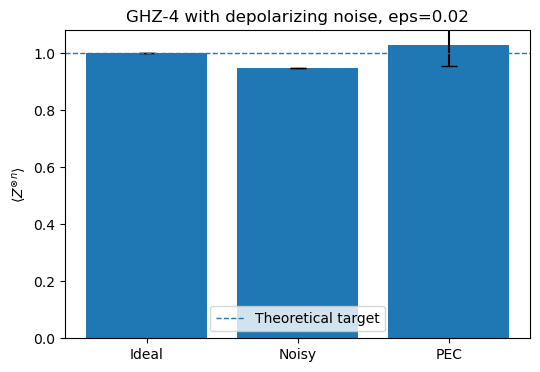

In [28]:
# === Provided: bar plot ===
labels = ["Ideal", "Noisy", "PEC"]
values = [theoretical_value, noisy_value, pec_value]
errors = [0.0, 0.0, 1.96 * pec_stderr]

plt.figure(figsize=(6, 4))
plt.bar(labels, values, yerr=errors, capsize=6)
plt.axhline(theoretical_value, linestyle="--", linewidth=1, label="Theoretical target")
plt.ylabel(r"$\langle Z^{\otimes n}\rangle$")
plt.ylim(0.0, 1.08)
plt.title(f"GHZ-{N_DEMO} with depolarizing noise, eps={EPS}")
plt.legend()
plt.show()

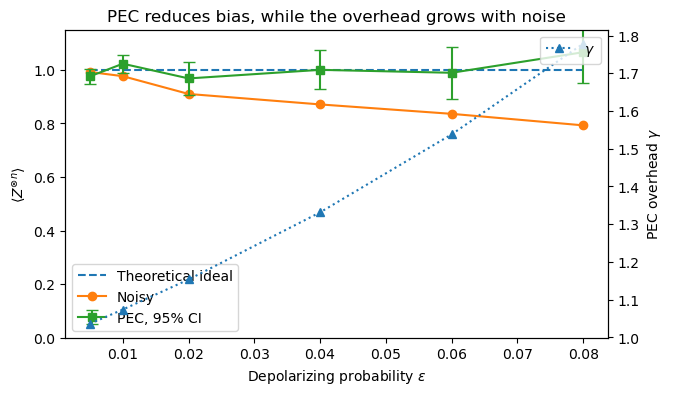

In [29]:
# === Provided: noise sweep ===
# This can take a few minutes because run_pec is shot-based.
eps_values = np.array([0.005, 0.01, 0.02, 0.04, 0.06, 0.08])

ideal_values = []
noisy_values = []
pec_values = []
pec_errors = []
gamma_values = []

for k, eps in enumerate(eps_values):
    ideal_values.append(execute(qc_demo, build_backend("ideal", eps, SEED + k), parity_observable, shots=SHOTS))
    noisy_values.append(execute(qc_demo, build_backend("dp", eps, SEED + k), parity_observable, shots=SHOTS))

    result = run_pec(qc_demo, eps, num_samples=250, shots=512, seed=SEED + 100 + k)
    pec_values.append(result["pec_value"])
    pec_errors.append(result["stderr"])
    gamma_values.append(result["gamma"])

ideal_values = np.array(ideal_values)
noisy_values = np.array(noisy_values)
pec_values = np.array(pec_values)
pec_errors = np.array(pec_errors)
gamma_values = np.array(gamma_values)

fig, ax1 = plt.subplots(figsize=(7, 4))
ax1.plot(eps_values, np.full_like(eps_values, theoretical_value, dtype=float), linestyle="--", label="Theoretical ideal")
ax1.plot(eps_values, noisy_values, marker="o", label="Noisy")
ax1.errorbar(eps_values, pec_values, yerr=1.96 * pec_errors, marker="s", capsize=4, label="PEC, 95% CI")
ax1.set_xlabel(r"Depolarizing probability $\epsilon$")
ax1.set_ylabel(r"$\langle Z^{\otimes n}\rangle$")
ax1.set_ylim(0.0, 1.15)
ax1.legend(loc="lower left")

ax2 = ax1.twinx()
ax2.plot(eps_values, gamma_values, linestyle=":", marker="^", label=r"$\gamma$")
ax2.set_ylabel(r"PEC overhead $\gamma$")
ax2.legend(loc="upper right")

plt.title("PEC reduces bias, while the overhead grows with noise")
plt.show()

<a id="tradeoff"></a>
# 6. The trade-off: exponential cost

PEC removes bias by sampling signed noisy circuits. The price is variance. If $\gamma$ is the
total overhead, the sample complexity for target statistical precision $\delta$ scales as

$$
M \approx \left(\frac{\gamma}{\delta}\right)^2.
$$


<a id="exercise_11"></a>
<div class="alert alert-block alert-success">
<b>Exercise 11 — Sample complexity</b>

<b>Your goal:</b> implement `required_samples(gamma, delta)`.

<b>Input:</b> overhead `gamma` and target standard error `delta`.

<b>Output:</b> the approximate number of PEC samples

$$M = (\gamma/\delta)^2.$$

Reject non-positive `delta` values.
</div>


In [30]:
# === Exercise 11 ===
# Define: required_samples(gamma: float, delta: float) -> float

def required_samples(gamma: float, delta: float) -> float:
    if delta <= 0:
        raise ValueError("delta must be positive.")
    return float((gamma / delta) ** 2)

In [31]:
# === Check Exercise 11 ===
grade_ex11(required_samples)

Exercise 11: PASS


True

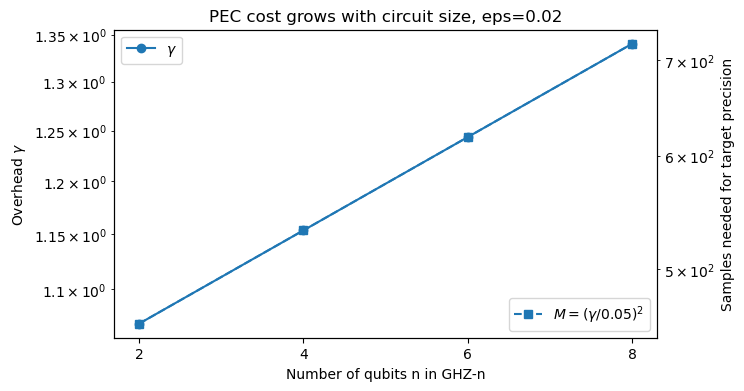

n=2: gamma=1.0700, M(delta=0.05)≈458
n=4: gamma=1.1535, M(delta=0.05)≈532
n=6: gamma=1.2435, M(delta=0.05)≈618
n=8: gamma=1.3405, M(delta=0.05)≈719


In [32]:
# === Provided: cost-vs-size sweep ===
# For even GHZ sizes, plot gamma and M = (gamma/delta)^2.
ns = np.array([2, 4, 6, 8])
delta = 0.05

gammas = np.array([pec_overhead(ghz_circuit(int(n)), EPS) for n in ns])
samples_needed = np.array([required_samples(g, delta) for g in gammas])

fig, ax1 = plt.subplots(figsize=(7, 4))
ax1.semilogy(ns, gammas, marker="o", label=r"$\gamma$")
ax1.set_xlabel("Number of qubits n in GHZ-n")
ax1.set_ylabel(r"Overhead $\gamma$")
ax1.set_xticks(ns)
ax1.legend(loc="upper left")

ax2 = ax1.twinx()
ax2.semilogy(ns, samples_needed, marker="s", linestyle="--", label=rf"$M=(\gamma/{delta})^2$")
ax2.set_ylabel("Samples needed for target precision")
ax2.legend(loc="lower right")

plt.title(f"PEC cost grows with circuit size, eps={EPS}")
plt.show()

for n, g, m in zip(ns, gammas, samples_needed):
    print(f"n={n}: gamma={g:.4f}, M(delta={delta})≈{m:.0f}")

### The main observations of PEC

- **PEC is unbiased in principle.** With enough samples, the signed average converges to the ideal expectation value.
- **PEC is expensive.** The sampling overhead grows with the number of noisy locations and the strength of the noise.
- **Noise-model consistency matters.** The Pauli insertions in this notebook are sampled inverse-noise terms. They are not independently noised by the Aer noise model.

<a id="conclusions"></a>
# 8. Conclusions

In this challenge you built Probabilistic Error Cancellation from its component parts: the
depolarizing quasiprobability tables, the sampling overhead $\gamma$, the Monte-Carlo sampling
step, and the unbiased estimator. You applied it to a GHZ circuit, confirmed that it recovers
the ideal expectation value where the raw noisy device cannot, and measured the exponential
variance cost that limits its use.

The headline to take away: **error mitigation buys accuracy with sampling, and PEC makes that
trade explicit through $\gamma$.** Unbiasedness is guaranteed only when the noise model matches
reality, and even then the cost grows exponentially with circuit size.


### Bonus challenges 🎯

If you finished and want to go further (no scaffolding provided — these are open-ended):

- **Amplitude-damping noise.** Depolarizing noise is the easy case because its inverse
  decomposes over Paulis. Amplitude damping is *non-unital* and needs a richer construction:
  extra single-qubit state preparations, an $\mathcal{S}^{\pm1}$ branch per gate, and a
  $P_{|0\rangle}$ "merge" step after each CNOT (Temme supplement, Sec. VI, Eqs. 39–41).
  Implement PEC for it and check the overhead $\gamma\le\big(\tfrac{1+\epsilon}{1-\epsilon}\big)^{L_1+2L_2}$.
- **Compare against Mitiq.** Reproduce your result using `mitiq.pec` and check the two
  estimates agree.
- **Randomized benchmarking circuits.** Replace GHZ with random Clifford circuits followed by
  their collective inverse, and study how $\gamma$ grows with circuit length.
- **Precision distribution.** Run many independent PEC estimates and compare the spread of the
  errors with the theoretical $\sigma \approx \gamma/\sqrt{M}$, in the style of Temme et al.
  (2017), Fig. 2/3.


<a id="refs"></a>
## References

1. K. Temme, S. Bravyi, J. M. Gambetta, *Error Mitigation for Short-Depth Quantum Circuits*,
   Phys. Rev. Lett. **119**, 180509 (2017). [arXiv:1612.02058](https://arxiv.org/abs/1612.02058)
   — and its Supplemental Material (the depolarizing and amplitude-damping QPR constructions).
2. Z. Cai *et al.*, *Quantum Error Mitigation*, Rev. Mod. Phys. **95**, 045005 (2023).
   [arXiv:2210.00921](https://arxiv.org/abs/2210.00921) — review; bias–variance trade-off and
   exponential sampling overhead.
3. R. Takagi, *Optimal resource cost for error mitigation*, Phys. Rev. Research **3**, 033178
   (2021). [arXiv:2006.12509](https://arxiv.org/abs/2006.12509) — optimality of the depolarizing
   decomposition.
4. Mitiq documentation — Probabilistic Error Cancellation:
   <https://mitiq.readthedocs.io/en/stable/guide/pec.html>
5. Qiskit Aer — building noise models:
   <https://qiskit.github.io/qiskit-aer/tutorials/3_building_noise_models.html>

---
